In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.metrics import classification_report, confusion_matrix

In [2]:
train_path = "dataset/Brain_MRI/train"
test_path = "dataset/Brain_MRI/test"

IMAGE_SIZE = (128,128)

BATCH_SIZE = 16

EPOCHS = 15

In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input,
    validation_split=0.2,
    rotation_range=15,
    zoom_range=0.15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=False
)

test_datagen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

In [4]:
train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="training",
    shuffle=True
)

validation_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="binary",
    shuffle=False
)

Found 163 images belonging to 2 classes.
Found 39 images belonging to 2 classes.
Found 51 images belonging to 2 classes.


In [13]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout

base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(128,128,3)
)

base_model.trainable = False

model = Sequential([
    base_model,
    GlobalAveragePooling2D(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_128 (Functional)    │ (None, 4, 4, 1280)          │       2,257,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ global_average_pooling2d_3           │ (None, 1280)                │               0 │
│ (GlobalAveragePooling2D)             │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 128)                 │         163,968 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_6 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_7 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,430,273 (9.27 MB)

 Trainable params: 172,289 (673.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [14]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [15]:
import os
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

os.makedirs("model", exist_ok=True)

checkpoint = ModelCheckpoint(
    "model/brain_mri_model.keras",
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True,
    verbose=1
)

In [16]:
model.optimizer

In [17]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=15,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 180ms/step - accuracy: 0.6135 - loss: 0.7481
Epoch 1: val_accuracy improved from None to 0.76923, saving model to model/brain_mri_model.keras

Epoch 1: finished saving model to model/brain_mri_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 14s 507ms/step - accuracy: 0.6135 - loss: 0.7481 - val_accuracy: 0.7692 - val_loss: 0.5016
Epoch 2/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - accuracy: 0.7423 - loss: 0.5650
Epoch 2: val_accuracy did not improve from 0.76923
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 290ms/step - accuracy: 0.7423 - loss: 0.5650 - val_accuracy: 0.7692 - val_loss: 0.4356
Epoch 3/15
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 212ms/step - accuracy: 0.7853 - loss: 0.4613
Epoch 3: val_accuracy improved from 0.76923 to 0.82051, saving model to model/brain_mri_model.keras

Epoch 3: finished saving model to model/brain_mri_model.keras
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 318ms/step - accuracy: 0.7853 - loss: 0.4613 - val_accuracy: 0.8205 - val_loss: 0.3981
Epoch 4/15
11/11

In [18]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Accuracy :", test_accuracy * 100)
print("Test Loss :", test_loss)

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 180ms/step - accuracy: 0.8627 - loss: 0.3341
Test Accuracy : 86.27451062202454
Test Loss : 0.3341248333454132


In [19]:
from sklearn.metrics import classification_report
import numpy as np

predictions = model.predict(test_generator)

predicted_classes = (predictions > 0.5).astype("int32")

print(classification_report(
    test_generator.classes,
    predicted_classes,
    target_names=list(test_generator.class_indices.keys())
))

4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step
              precision    recall  f1-score   support

          no       0.78      0.90      0.84        20
         yes       0.93      0.84      0.88        31

    accuracy                           0.86        51
   macro avg       0.86      0.87      0.86        51
weighted avg       0.87      0.86      0.86        51



In [20]:
class_names = list(train_generator.class_indices.keys())

with open("model/brain_classes.txt", "w") as f:
    for cls in class_names:
        f.write(cls + "\n")

print("brain_classes.txt saved successfully.")

brain_classes.txt saved successfully.


In [21]:
img_path = r"C:\Users\deshp\Downloads\archive\brain_tumor_dataset\yes\Y1.jpg"

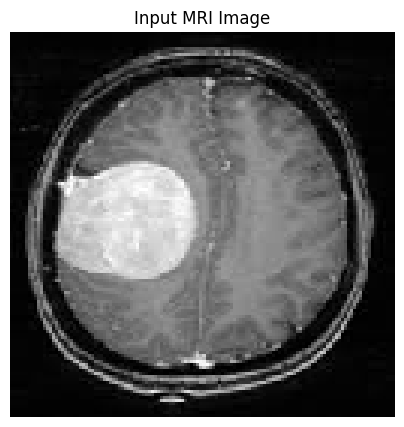

Predicted Class : yes
Confidence      : 99.31 %


In [22]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image

# ===========================================
# Enter MRI Image Path
# ===========================================
img_path = r"C:\Users\deshp\Downloads\archive\brain_tumor_dataset\yes\Y1.jpg"

# ===========================================
# Load Image
# ===========================================
img = image.load_img(img_path, target_size=(128, 128))

plt.figure(figsize=(5,5))
plt.imshow(img)
plt.title("Input MRI Image")
plt.axis("off")
plt.show()

# ===========================================
# Preprocess Image
# ===========================================
img_array = image.img_to_array(img)
img_array = tf.keras.applications.mobilenet_v2.preprocess_input(img_array)
img_array = np.expand_dims(img_array, axis=0)

# ===========================================
# Predict
# ===========================================
prediction = model.predict(img_array, verbose=0)[0][0]

# ===========================================
# Load Class Names
# ===========================================
with open("model/brain_classes.txt", "r") as f:
    class_names = [line.strip() for line in f.readlines()]

# ===========================================
# Display Result
# ===========================================
if prediction >= 0.5:
    predicted_class = class_names[1]
    confidence = prediction * 100
else:
    predicted_class = class_names[0]
    confidence = (1 - prediction) * 100

print("=" * 40)
print("Predicted Class :", predicted_class)
print("Confidence      :", round(float(confidence), 2), "%")
print("=" * 40)